In [1]:
from datetime import datetime,timedelta,date
import pandas as pd
import numpy as np


#
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.offline as pyoff
import plotly.graph_objects as go

#
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.svm import SVC
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from sklearn.model_selection import KFold,cross_val_score,train_test_split

In [94]:
tx_data=pd.read_csv(r'C:\Users\jedat\Downloads\Data Analyst BT\Python-VTI-DAS-2513\Python_SQL_project\Dataset\OnlineRetail.csv',encoding='ISO-8859-1')
tx_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [95]:
tx_data['InvoiceDate']=pd.to_datetime(tx_data['InvoiceDate']).dt.normalize()
tx_data.head()
tx_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  str           
 1   StockCode    541909 non-null  str           
 2   Description  540455 non-null  str           
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 33.1 MB


In [96]:
#Lọc lấy country là Kingdom để dự đoán
tx_uk=tx_data.query("Country=='United Kingdom'").reset_index(drop=True)
tx_uk.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01,3.39,17850.0,United Kingdom


In [97]:
#Lấy data T3-T9
tx_6m=tx_uk[(tx_uk['InvoiceDate']< '2011-09-01') & (tx_uk['InvoiceDate'] >= '2011-03-01')].reset_index(drop=True)
#tx_6m.head()


# Lấy Data từ tháng 9 -12 để dự đoán
tx_next=tx_uk[(tx_uk['InvoiceDate']>= '2011-09-01') & (tx_uk['InvoiceDate']< '2011-12-01')].reset_index(drop=True)
#tx_next.head()


#Lấy customer unique
tx_user=pd.DataFrame(tx_6m['CustomerID'].unique())
tx_user.columns= ['CustomerID']
tx_user.head()

,CustomerID
0,14620.0
1,14740.0
2,13880.0
3,16462.0
4,17068.0


In [98]:
#Adding Label

#Lấy ngày mua hàng đâu tiên của T9-T12
tx_next_first_purchase=tx_next.groupby('CustomerID')['InvoiceDate'].min().reset_index()
tx_next_first_purchase.columns=['CustomerID','MinPurchaseDate']
#tx_next_first_purchase.head()


#Lấy ngày cuối cùng mua hàng từ T3-T9
tx_last_purchase=tx_6m.groupby('CustomerID')['InvoiceDate'].max().reset_index()
tx_last_purchase.columns=['CustomerID','MaxPurchaseDate']
#tx_last_purchase.head()


#Merge 2 bảng trên
tx_purchase_dates=pd.merge(tx_last_purchase,tx_next_first_purchase,on='CustomerID',how='left')
#tx_purchase_dates.head()


#Tính ngày khoảng cách ngày mua hàng cuối cùng, đến ngày mua hàng đầu tiên trong T9-T12
tx_purchase_dates['NextPurchaseDay']= (tx_purchase_dates['MinPurchaseDate'] - tx_purchase_dates['MaxPurchaseDate']).dt.days
#tx_purchase_dates.head()


#Merge tx_user và tx_purchase_dates
tx_user=pd.merge(tx_user,tx_purchase_dates[['CustomerID','NextPurchaseDay']],on='CustomerID',how='left')
tx_user=tx_user.fillna(999)
tx_user.head()

,CustomerID,NextPurchaseDay
0,14620.0,999.0
1,14740.0,999.0
2,13880.0,58.0
3,16462.0,112.0
4,17068.0,16.0


In [99]:
# ================ Feature Engineering ================ 
# Selected our feature candidates like below:
    # RFM scores & clussters
    # Days between the last three purchases
    # Mean & standard deviation of the difference between purchases in days
    # After adding these features, we need to deal with the categorical features by applying get_dummies method



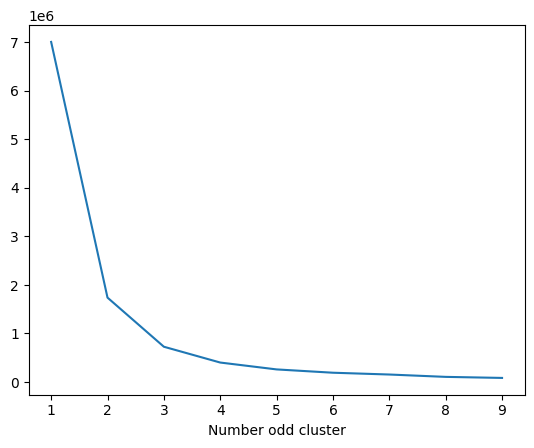

,CustomerID,NextPurchaseDay,Recency,RecencyCluster
0,14620.0,999.0,104,1
1,14740.0,999.0,91,1
2,13880.0,58.0,45,2
3,16462.0,112.0,85,1
4,17068.0,16.0,10,3


In [ ]:
#1 RFM scores & Clussters

# Tính Recency
tx_max_purchase= tx_6m.groupby('CustomerID')['InvoiceDate'].max().reset_index()
tx_max_purchase.columns=['CustomerID','MaxPurchaseDate']
tx_max_purchase['Recency']=(tx_max_purchase['MaxPurchaseDate'].max() - tx_max_purchase['MaxPurchaseDate']).dt.days
tx_max_purchase.head()


# Merge
if 'Recency' in tx_user.columns:
    tx_user = tx_user.drop(columns=['Recency']) #Tránh lỗi chạy cell nhiều lần bị dup   

tx_user=pd.merge(tx_user,tx_max_purchase[['CustomerID','Recency']],on='CustomerID')
tx_user.head ()


# Clustering cho Recency
sse={}
tx_recency=tx_user[['Recency']] #Bắt buộc "[['Recency']]" vì thuật toán Kmeans yêu cầu
for k in range(1,10):
    kmeans=KMeans(n_clusters=k,max_iter=1000).fit(tx_recency) #thuật toán kmeans
    tx_recency['clusers']=kmeans.labels_
    sse[k]=kmeans.inertia_
plt.figure()
plt.plot(list(sse.keys()),list(sse.values()))
plt.xlabel("Number odd cluster")
plt.show()

kmeans=KMeans(n_clusters=4) 
kmeans.fit(tx_user[['Recency']])
tx_user['RecencyCluster']=kmeans.predict(tx_user[['Recency']])
tx_user.head()

#Sắp sếp lại Recency cluster từ lớn tới bé
#tx_user.groupby('RecencyCluster')['Recency'].describe()

def order_cluster(cluster_field_name,target_field_name,df,ascending):
    new_cluster_field_name= "new_ " + cluster_field_name
    df_new=df.groupby(cluster_field_name)[target_field_name].mean().reset_index()
    df_new=df_new.sort_values(by=target_field_name,ascending=ascending).reset_index(drop=True)
    df_new['index']=df_new.index
    df_final=pd.merge(df,df_new[[cluster_field_name,'index']],on=cluster_field_name)
    df_final=df_final.drop([cluster_field_name],axis=1)
    df_final=df_final.rename(columns={"index":cluster_field_name})
    return df_final

tx_user=order_cluster('RecencyCluster','Recency',tx_user,False)
tx_user.groupby('RecencyCluster')['Recency'].describe()
tx_user.head()


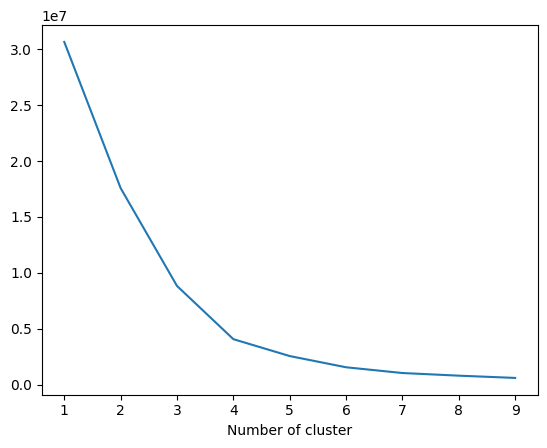

CustomerID                                                \
                      count          mean          std      min       25%   
FrequencyCluster                                                            
0                    2238.0  15530.291332  1579.293775  12747.0  14161.25   
1                     313.0  15583.913738  1573.474634  12749.0  14286.00   
2                      16.0  14869.562500  1386.584820  12748.0  14133.25   
3                       1.0  17841.000000          NaN  17841.0  17841.00   

                                             NextPurchaseDay              ...  \
                      50%       75%      max           count        mean  ...   
FrequencyCluster                                                          ...   
0                 15529.0  16880.75  18287.0          2238.0  495.323950  ...   
1                 15615.0  16928.00  18283.0           313.0  144.392971  ...   
2                 14782.5  15413.00  18118.0            16.0   20.625000  ...   
3                 17841.0  17841.00  17841.0             1.0    4.000000  ...   

                 RecencyCluster      Frequency                           \
                            75%  max     count         mean         std   
FrequencyCluster                                                          
0                           3.0  3.0    2238.0    31.698391   25.994028   
1                           3.0  3.0     313.0   182.198083   70.504222   
2                           3.0  3.0      16.0   766.062500  260.797103   
3                           3.0  3.0       1.0  3546.000000         NaN   

                                                           
                     min      25%     50%     75%     max  
FrequencyCluster                                           
0                    1.0    11.00    23.0    46.0   106.0  
1                  107.0   130.00   160.0   212.0   450.0  
2                  510.0   555.75   646.5   936.5  1251.0  
3                 3546.0  3546.00  3546.0  3546.0  3546.0  

[4 rows x 40 columns]

In [101]:
# Tính Frequency
tx_frequency=tx_6m.groupby('CustomerID')['InvoiceDate'].count().reset_index()
tx_frequency.columns=['CustomerID','Frequency']
tx_frequency.head()

#Merge Frquency
if 'Frequency' in tx_user.columns:
    tx_user = tx_user.drop(columns=['Frequency'])
tx_user=pd.merge(tx_user,tx_frequency,on='CustomerID')
tx_user.head()
tx_user.Frequency.describe()

#Clustering cho Frequency
sse={}
tx_frequency=tx_user[['Frequency']]
for k in range(1,10):
    kmeans=KMeans(n_clusters=k,max_iter=1000).fit(tx_frequency)
    tx_frequency['Clusters']=kmeans.labels_
    sse[k]=kmeans.inertia_
plt.figure()
plt.plot(list(sse.keys()),list(sse.values()))
plt.xlabel("Number of cluster")
plt.show ()

#Lấy ra số cụm
kmeans=KMeans(n_clusters=4)
kmeans.fit(tx_user[['Frequency']])
tx_user['FrequencyCluster']=kmeans.predict(tx_user[['Frequency']])

tx_user=order_cluster('FrequencyCluster','Frequency',tx_user,True) #Đoạn Def này đã viết ở Cell trên
tx_user.groupby('FrequencyCluster').describe()




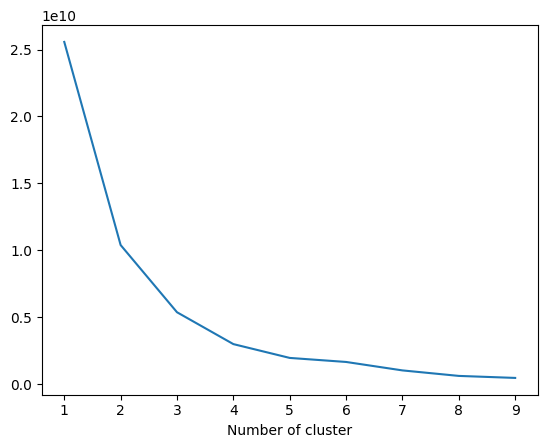

,count,mean,std,min,25%,50%,75%,max
RevenueCluster,,,,,,,,
0,2473.0,698.675407,736.240871,-4287.63,214.8000,417.380,919.6100,3969.55
1,83.0,7267.950000,3573.277677,4019.00,4679.1550,5472.000,9321.1200,17886.66
2,10.0,28550.553000,6468.513253,20990.36,23262.9325,27522.795,32660.5400,37934.22
3,2.0,76665.615000,17370.382136,64382.90,70524.2575,76665.615,82806.9725,88948.33


In [102]:
#Tính Monetary Value
tx_6m['Revenue']=tx_6m['UnitPrice'] * tx_6m['Quantity']
tx_revenue=tx_6m.groupby('CustomerID')['Revenue'].sum().reset_index()
tx_revenue.head()

#Merge tx_user với tx_revenue
if 'Revenue' in tx_user.columns:
    tx_user=tx_user.drop(columns=['Revenue'])
tx_user=pd.merge(tx_user,tx_revenue,on='CustomerID')
tx_user.Revenue.describe()

#Tính Clustering cho Monetary
tx_revenue=tx_user[['Revenue']]
for k in range (1,10):
    kmeans=KMeans(n_clusters=k,max_iter=1000).fit(tx_revenue)
    tx_revenue['clusters']=kmeans.labels_
    sse[k]=kmeans.inertia_
plt.figure()
plt.plot(list(sse.keys()),list(sse.values()))
plt.xlabel("Number of cluster")
plt.show()

#Phân cụm Revenue
kmeans=KMeans(n_clusters=4)
kmeans.fit(tx_user[['Revenue']])
tx_user['RevenueCluster']=kmeans.predict(tx_user[['Revenue']])



tx_user=order_cluster('RevenueCluster','Revenue',tx_user,True) #Đoạn def này đã được viết ở cell trên
tx_user.groupby('RevenueCluster')['Revenue'].describe()



In [103]:
#Overall Segmentation
tx_user['OverallScore']=tx_user['RecencyCluster']+tx_user['FrequencyCluster']+tx_user['RevenueCluster']
tx_user.groupby('OverallScore')[['Recency','Frequency','Revenue']].mean()

tx_user.groupby('OverallScore')['Recency'].count()

tx_user['Segment']='Low-Value'
tx_user.loc[tx_user['OverallScore']>2,'Segment']='Mid-value'
tx_user.loc[tx_user['OverallScore']>4,'Segment']='High-Value'

tx_user.head()


,CustomerID,NextPurchaseDay,Recency,RecencyCluster,Frequency,FrequencyCluster,Revenue,RevenueCluster,OverallScore,Segment
0,14620.0,999.0,104,1,30,0,393.28,0,1,Low-Value
1,14740.0,999.0,91,1,93,0,1423.21,0,1,Low-Value
2,13880.0,58.0,45,2,71,0,1372.76,0,2,Low-Value
3,16462.0,112.0,85,1,2,0,68.00,0,1,Low-Value
4,17068.0,16.0,10,3,140,1,2405.54,0,4,Mid-value


In [120]:
# ================ Adding new features =============

#2 Days between the last three purchases
tx_6m.head()

#Create a dataframe with CustomerID and Invoice Date
tx_day_order=tx_6m[['CustomerID','InvoiceDate']]

#Create and convert Invoice Datetime to day
tx_day_order['InvoiceDay']=pd.to_datetime(tx_6m['InvoiceDate'])
tx_day_order=tx_day_order.sort_values(['CustomerID','InvoiceDate'])

#Drop Duplicate
tx_day_order=tx_day_order.drop_duplicates(subset=['CustomerID','InvoiceDay'],keep='first')

#Shifting last 3 purchase dates 
tx_day_order['PrevInvoiceDate']=tx_day_order.groupby('CustomerID')['InvoiceDay'].shift(1)
tx_day_order['Prev2InvoiceDate']=tx_day_order.groupby('CustomerID')['InvoiceDay'].shift(2)
tx_day_order['Prev3InvoiceDate']=tx_day_order.groupby('CustomerID')['InvoiceDay'].shift(3)

# Tính DayDiff
tx_day_order['DayDiff']= (tx_day_order['InvoiceDay']-tx_day_order['PrevInvoiceDate']).dt.days
tx_day_order['DayDiff2']=(tx_day_order['InvoiceDay']-tx_day_order['Prev2InvoiceDate']).dt.days
tx_day_order['DayDiff3']=(tx_day_order['InvoiceDay']-tx_day_order['Prev3InvoiceDate']).dt.days

#Tính mean và std
tx_day_diff=tx_day_order.groupby('CustomerID').agg({'DayDiff':['mean','std']}).reset_index()
tx_day_diff.columns=['CustomerID','DayDiffMean','DayDiffStd']
#print(tx_day_diff)


tx_day_order_last=tx_day_order.drop_duplicates(subset=['CustomerID'],keep='last').sort_values(by='CustomerID')
tx_day_order_last=tx_day_order_last.drop(columns=[c for c in ['DayDIffMean','DayDiffStd'] if c in tx_day_order_last.columns]) #Nếu chạy lần 2 cell này, sẽ không bị lỗi
tx_day_order_last=pd.merge(tx_day_diff,tx_day_order_last,on='CustomerID')
#print(tx_day_order_last.head())


tx_user=tx_user.drop(columns=[c for c in ['DayDiff','DayDiff2','DayDiff3','DayDiffMean','DayDiffStd'] if c in tx_user.columns])
tx_user=pd.merge(tx_user,tx_day_order_last[['CustomerID','DayDiff','DayDiff2','DayDiff3','DayDiffMean','DayDiffStd']],on='CustomerID',how='left')
tx_user=tx_user.dropna()
tx_user


,CustomerID,NextPurchaseDay,Recency,RecencyCluster,Frequency,FrequencyCluster,Revenue,RevenueCluster,OverallScore,Segment,DayDiff,DayDiff2,DayDiff3,DayDiffMean,DayDiffStd
1,14740.0,999.0,91,1,93,0,1423.21,0,1,Low-Value,6.0,34.0,92.0,30.666667,26.102363
2,13880.0,58.0,45,2,71,0,1372.76,0,2,Low-Value,41.0,72.0,93.0,34.500000,10.754844
4,17068.0,16.0,10,3,140,1,2405.54,0,4,Mid-value,25.0,37.0,38.0,17.300000,11.045864
5,12971.0,8.0,7,3,146,1,5959.04,1,5,High-Value,3.0,7.0,19.0,5.333333,3.619968
7,16915.0,83.0,27,3,31,0,382.39,0,3,Mid-value,41.0,121.0,156.0,52.000000,24.433583
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2130,17750.0,14.0,13,3,127,1,1079.72,0,4,Mid-value,20.0,34.0,51.0,17.000000,3.000000
2132,17997.0,35.0,33,3,76,0,1276.72,0,3,Mid-value,19.0,23.0,31.0,10.333333,7.767453
2183,13217.0,999.0,22,3,7,0,133.62,0,3,Mid-value,9.0,20.0,34.0,11.333333,2.516611
2350,14414.0,10.0,9,3,66,0,908.03,0,3,Mid-value,5.0,22.0,24.0,6.750000,6.946222


,CustomerID,NextPurchaseDay,Recency,RecencyCluster,Frequency,FrequencyCluster,Revenue,RevenueCluster,OverallScore,DayDiff,DayDiff2,DayDiff3,DayDiffMean,DayDiffStd,Segment_High-Value,Segment_Low-Value,Segment_Mid-value
1,14740.0,999.0,91,1,93,0,1423.21,0,1,6.0,34.0,92.0,30.666667,26.102363,0,1,0
2,13880.0,58.0,45,2,71,0,1372.76,0,2,41.0,72.0,93.0,34.500000,10.754844,0,1,0
4,17068.0,16.0,10,3,140,1,2405.54,0,4,25.0,37.0,38.0,17.300000,11.045864,0,0,1
5,12971.0,8.0,7,3,146,1,5959.04,1,5,3.0,7.0,19.0,5.333333,3.619968,1,0,0
7,16915.0,83.0,27,3,31,0,382.39,0,3,41.0,121.0,156.0,52.000000,24.433583,0,0,1


In [130]:
# Grouping the Label 
tx_class=tx_user.copy()
tx_class=pd.get_dummies(tx_class,dtype=int) #Nếu không có dtype thì nó sẽ ra dạng True, False
tx_class.head()

#===================== Modeling ===================

# Tạo thêm 1 features nữa
tx_class['NextPurchaseDayRange']=2
tx_class.loc[tx_class['NextPurchaseDay'] >20,'NextPurchaseDayRange']=1
tx_class.loc[tx_class['NextPurchaseDay'] >50,'NextPurchaseDayRange']=0
#tx_class['NextPurchaseDayRange'].value_counts()/len(tx_user)*100



#Biểu đồ tương quan
# corr=tx_class[tx_class.columns].corr()
# plt.figure(figsize=(30,20))
# sns.heatmap(corr,annot=True,linewidths=0.2,fmt=".2f")


#Training Machine
tx_class=tx_class.drop('NextPurchaseDay',axis=1) # NextPurchaseDay và NextPurchaseDayRange gần như tương quan giống nhau =>  bỏ NextPurchaseDay
X=tx_class.drop(columns=['NextPurchaseDayRange'])
y=tx_class['NextPurchaseDayRange']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


#Models
models=[]
models.append(('LR',LogisticRegression()))
models.append(("NB",GaussianNB()))
models.append(("RF",RandomForestClassifier()))
models.append(("SVC",SVC()))
models.append(("Dtre",DecisionTreeClassifier()))
models.append(("XGB",xgb.XGBClassifier()))
models.append(("KNN",KNeighborsClassifier()))

for name,model in models:
    kfold=KFold(n_splits=2)
    cv_result=cross_val_score(model,X_train,y_train,cv=kfold,scoring="accuracy")
    print(name,cv_result)


xgb_model=xgb.XGBClassifier().fit(X_train,y_train)

print('Accuracy of XGB classifier on training set: {:.2f}'.format(xgb_model.score(X_train,y_train)))
print('Accuracy of XGB classifier on training set: {:.2f}'.format(xgb_model.score(X_test[X_train.columns],y_test)))

y_pred=xgb_model.predict(X_test)
print(classification_report(y_test,y_pred))


# Retrain
from sklearn.model_selection import GridSearchCV

param_test1={
    'max_depth':range(3,10,2),
    'min_child_weight':range(1,6,2)
}
gsearch1=GridSearchCV(estimator=xgb.XGBClassifier(),param_grid=param_test1,scoring='accuracy')
gsearch1.fit(X_train,y_train)
gsearch1.best_params_, gsearch1.best_score_

xgb_model=xgb.XGBClassifier(max_depth=7,min_child_weight=3).fit(X_train,y_train)
print('Accuracy of XGB classifier on training set: {:.2f}'.format(xgb_model.score(X_train,y_train)))
print('Accuracy of XGB classifier on training set: {:.2f}'.format(xgb_model.score(X_test[X_train.columns],y_test)))

y_pred=xgb_model.predict(X_test)
len(y_pred)
X_test['Preict_NextPurchaseRange']=y_pred
print(classification_report(y_test,y_pred))

#tx_class.head()

c:\Users\jedat\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\jedat\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://sciki

LR [0.57028112 0.6184739 ]
NB [0.61044177 0.57028112]
RF [0.59437751 0.57831325]
SVC [0.4497992  0.51807229]
Dtre [0.58232932 0.57831325]
XGB [0.64658635 0.58232932]
KNN [0.48995984 0.48594378]
Accuracy of XGB classifier on training set: 1.00
Accuracy of XGB classifier on training set: 0.61
              precision    recall  f1-score   support

           0       0.75      0.72      0.73        57
           1       0.48      0.54      0.51        41
           2       0.54      0.48      0.51        27

    accuracy                           0.61       125
   macro avg       0.59      0.58      0.58       125
weighted avg       0.61      0.61      0.61       125

Accuracy of XGB classifier on training set: 1.00
Accuracy of XGB classifier on training set: 0.60
              precision    recall  f1-score   support

           0       0.74      0.68      0.71        57
           1       0.47      0.49      0.48        41
           2       0.55      0.59      0.57        27

    accurac

In [128]:
#Xem kết quả
tx_class.sort_values(by='CustomerID')

,CustomerID,Recency,RecencyCluster,Frequency,FrequencyCluster,Revenue,RevenueCluster,OverallScore,DayDiff,DayDiff2,DayDiff3,DayDiffMean,DayDiffStd,Segment_High-Value,Segment_Low-Value,Segment_Mid-value,NextPurchaseDayRange
34,12747.0,9,3,50,0,1760.09,0,3,55.0,89.0,109.0,43.500000,20.305993,0,0,1,1
277,12748.0,1,3,1210,2,8115.68,1,6,5.0,6.0,13.0,3.723404,3.083632,1,0,0,2
1586,12749.0,13,3,160,1,2532.55,0,4,7.0,17.0,87.0,25.000000,30.099834,0,0,1,0
2060,12830.0,34,3,28,0,5137.76,1,4,7.0,22.0,37.0,12.333333,4.618802,0,0,1,1
225,12839.0,13,3,101,0,1591.50,0,3,20.0,44.0,70.0,32.800000,26.166773,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1895,18248.0,13,3,49,0,783.02,0,3,1.0,9.0,73.0,24.333333,34.530180,0,0,1,0
215,18257.0,14,3,68,0,1141.82,0,3,54.0,77.0,86.0,32.600000,28.675774,0,0,1,1
448,18260.0,72,2,100,0,1825.48,0,2,28.0,33.0,68.0,24.250000,13.200379,0,1,0,0
1036,18272.0,13,3,118,1,2092.65,0,4,37.0,99.0,112.0,33.250000,21.608255,0,0,1,0
